In [44]:
import pandas as pd 

data = pd.read_csv("./Attendance_Prediction.csv")
data.head(5)

,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


In [45]:
data.shape

(20000, 15)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           20000 non-null  float64
 1   age                  20000 non-null  int64  
 2   gender               20000 non-null  object 
 3   course               20000 non-null  object 
 4   year                 20000 non-null  object 
 5   parent_education     20000 non-null  object 
 6   internet_access      20000 non-null  object 
 7   hostel_resident      20000 non-null  object 
 8   class_type           20000 non-null  object 
 9   weather              20000 non-null  object 
 10  study_hours          20000 non-null  float64
 11  sleep_hours          20000 non-null  float64
 12  travel_time_minutes  20000 non-null  int64  
 13  attendance           20000 non-null  int64  
 14  absence_reason       20000 non-null  object 
dtypes: float64(3), int64(3), object(9)
m

In [47]:
data.isnull().sum()

student_id             0
age                    0
gender                 0
course                 0
year                   0
parent_education       0
internet_access        0
hostel_resident        0
class_type             0
weather                0
study_hours            0
sleep_hours            0
travel_time_minutes    0
attendance             0
absence_reason         0
dtype: int64

In [48]:
data.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'parent_education',
       'internet_access', 'hostel_resident', 'class_type', 'weather',
       'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance',
       'absence_reason'],
      dtype='object')

In [49]:
#identification des variables qualitatives pour savoir le nombre de modalités par variable:

qualitative_cols = data.select_dtypes(include=['object', 'category']).columns
qualitative_cols

Index(['gender', 'course', 'year', 'parent_education', 'internet_access',
       'hostel_resident', 'class_type', 'weather', 'absence_reason'],
      dtype='object')

In [50]:
#voir si la suppression des individus avec 'gender = other' va impacter le dataset:
nombre_individus_other = data[data['gender'] == 'other'].shape[0]
nombre_individus_other

6726

In [51]:
data = data.drop(columns=[
    'age', 'study_hours', 'travel_time_minutes',
    'attendance', 'parent_education', 'student_id' , 'hostel_resident'
])

data = data[data['gender'] != 'other']

data.head()


,gender,course,year,internet_access,class_type,weather,sleep_hours,absence_reason
0,male,pharmacy,1st year,no,offline,sunny,7.24,none
2,male,b.sc,3rd year,yes,online,rainy,6.53,none
4,female,pharmacy,1st year,yes,online,sunny,9.35,project work
5,male,b.tech,4th year,yes,offline,hot,9.36,none
6,female,b.tech,1st year,yes,offline,cloudy,4.96,none


In [52]:
data = data.iloc[:1000].copy()

In [53]:
# Compter le nombre de modalités par variable.
qualitative_cols = data.select_dtypes(include=['object', 'category']).columns
for col in qualitative_cols:
    nombre_modalites = data[col].nunique()
    print(f"- {col}  : {nombre_modalites} modalités")

- gender  : 2 modalités
- course  : 9 modalités
- year  : 4 modalités
- internet_access  : 2 modalités
- class_type  : 2 modalités
- weather  : 5 modalités
- absence_reason  : 7 modalités


C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


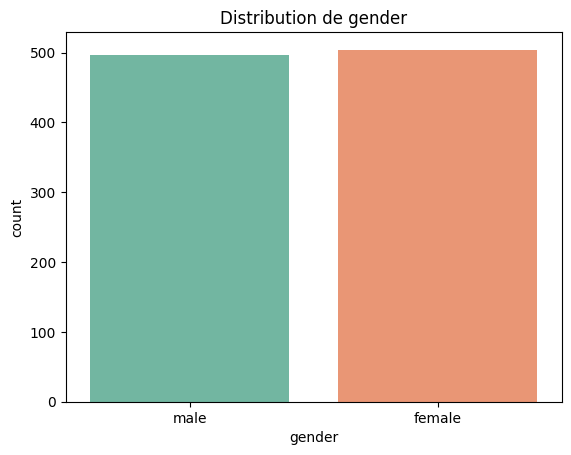

C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


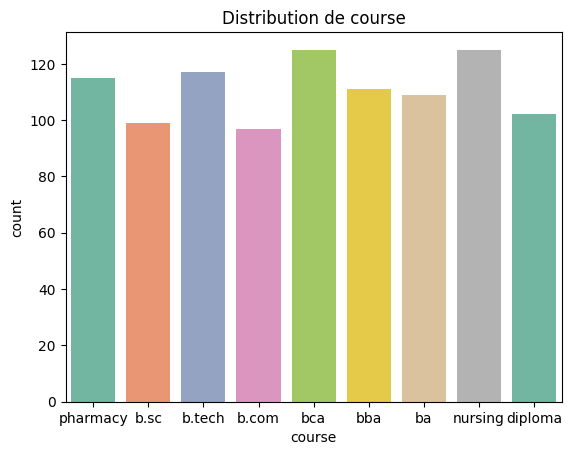

C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


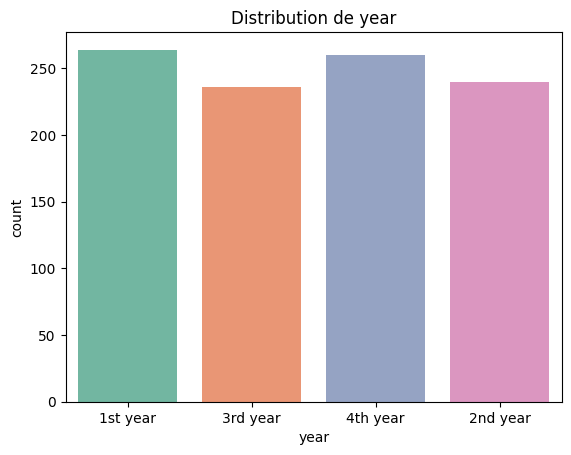

C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


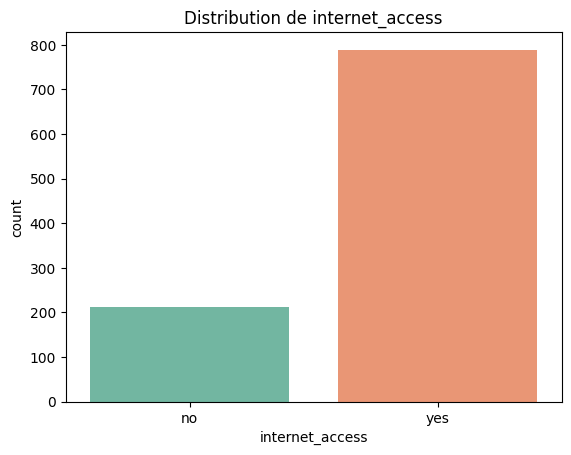

C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


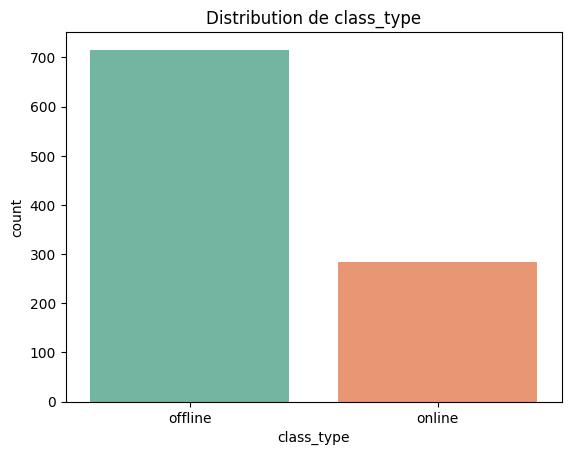

C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


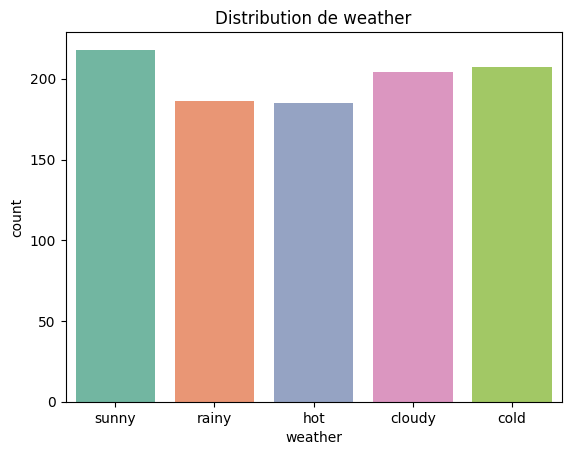

C:\Users\PC\AppData\Local\Temp\ipykernel_17896\739820038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")


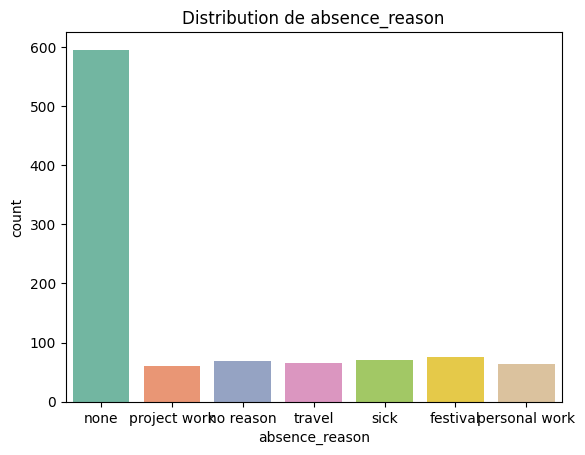

In [54]:
# Produire un tableau de fréquence et un diagramme en barres.
import matplotlib.pyplot as plt
import seaborn as sns
for col in qualitative_cols:
    sns.countplot(data=data, x=col, palette="Set2")
    plt.title(f"Distribution de {col}")
    plt.show()

In [55]:
quantitative_cols = data.select_dtypes(include=['number'])
quantitative_cols.describe()

,sleep_hours
count,1000.000000
mean,7.035070
std,1.734107
min,4.060000
25%,5.500000
50%,7.035000
75%,8.522500
max,9.940000


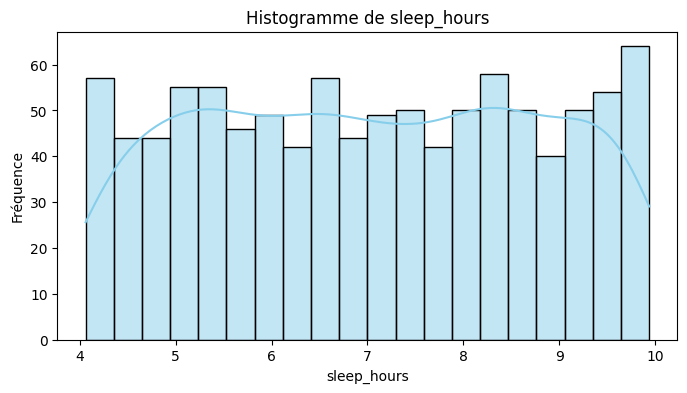

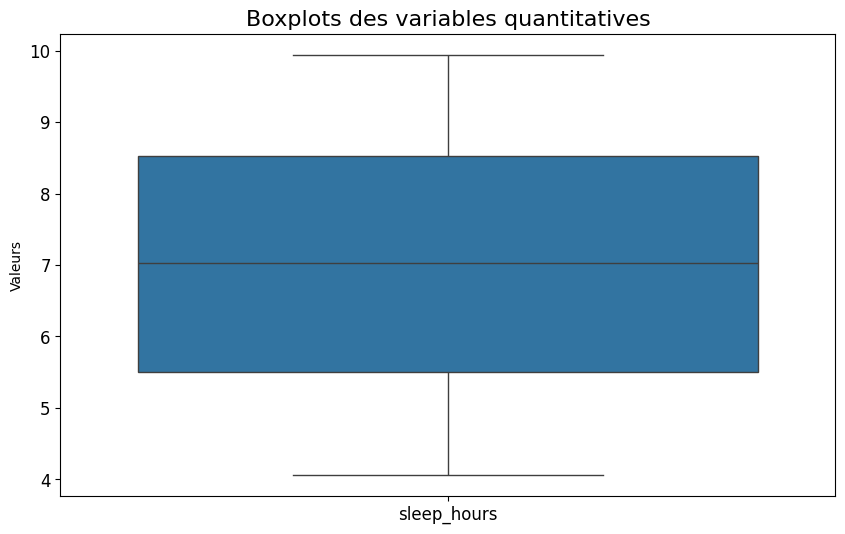

In [56]:
# Produire un histogramme et éventuellement une boxplot pour visualiser la distribution.
# Histogramme
quantitatives = quantitative_cols.columns
for col in quantitatives:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Histogramme de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=quantitative_cols)
plt.title("Boxplots des variables quantitatives", fontsize=16)
plt.ylabel("Valeurs")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Analyse multivariée En utilisant l'ACM
    Pour les variables qualitatives.
    Voir les relations entre modalités de différentes variables.

    - Mais avant d'effectuer l'ACM, Les variables quantitatives (travel_time_minutes) doivent être discrétisées (transformées en catégories : 'Court', 'Moyen', 'Long' ) avant de les inclure dans l’ACM car L’ACM ne   fonctionne que sur variables qualitatives.

In [57]:
bins = [0, 7, 8.5, 10]
labels = ['Court', 'Moyen', 'Long']

data['sleep_time'] = pd.cut(data['sleep_hours'], bins=bins, labels=labels)

df = data.drop(columns=['sleep_hours'])

In [58]:
df.head()

,gender,course,year,internet_access,class_type,weather,absence_reason,sleep_time
0,male,pharmacy,1st year,no,offline,sunny,none,Moyen
2,male,b.sc,3rd year,yes,online,rainy,none,Court
4,female,pharmacy,1st year,yes,online,sunny,project work,Long
5,male,b.tech,4th year,yes,offline,hot,none,Long
6,female,b.tech,1st year,yes,offline,cloudy,none,Court


In [59]:
#sauvegarder
new_file_name = 'corrected_dataset.csv'
df.to_csv(new_file_name, index=False)